# Datathon PosTech — Passos Mágicos
## Notebook 1 — Exploração Inicial dos Dados

Este notebook realiza a carga, limpeza e exploração inicial da base PEDE (2022, 2023 e 2024).

**Objetivos:**
- Entender a estrutura dos dados
- Identificar nulos, inconsistências e distribuições
- Consolidar os três anos em um único dataset


## 1. Imports e configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAF8',
    'font.size': 10
})

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


## 2. Carregamento dos dados

In [2]:
# Ajuste o caminho conforme sua estrutura local
PATH = '../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

df22 = pd.read_excel(PATH, sheet_name='PEDE2022')
df23 = pd.read_excel(PATH, sheet_name='PEDE2023')
df24 = pd.read_excel(PATH, sheet_name='PEDE2024')

print(f"2022: {df22.shape[0]} alunos | {df22.shape[1]} colunas")
print(f"2023: {df23.shape[0]} alunos | {df23.shape[1]} colunas")
print(f"2024: {df24.shape[0]} alunos | {df24.shape[1]} colunas")


2022: 860 alunos | 42 colunas
2023: 1014 alunos | 48 colunas
2024: 1156 alunos | 50 colunas


### 2.1 Inspeção das colunas por ano

In [3]:
print("=== Colunas 2022 ===")
print(df22.columns.tolist())
print("\n=== Colunas 2023 ===")
print(df23.columns.tolist())
print("\n=== Colunas 2024 ===")
print(df24.columns.tolist())


=== Colunas 2022 ===
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

=== Colunas 2023 ===
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Dest

## 3. Normalização e consolidação

In [4]:
# Padronizar nomes de colunas entre os anos
df22 = df22.rename(columns={
    'INDE 22':'INDE', 'Gênero':'Genero', 'Fase ideal':'Fase_Ideal',
    'Atingiu PV':'Atingiu_PV', 'Matem':'Mat', 'Portug':'Por',
    'Inglês':'Ing', 'Pedra 22':'Pedra', 'Defas':'Defasagem'
})
df22['Ano'] = 2022
df22['IPP'] = np.nan

df23 = df23.rename(columns={
    'INDE 2023':'INDE', 'Gênero':'Genero', 'Fase Ideal':'Fase_Ideal',
    'Atingiu PV':'Atingiu_PV', 'Nome Anonimizado':'Nome', 'Pedra 2023':'Pedra'
})
df23['Ano'] = 2023

df24 = df24.rename(columns={
    'INDE 2024':'INDE', 'Gênero':'Genero', 'Fase Ideal':'Fase_Ideal',
    'Atingiu PV':'Atingiu_PV', 'Nome Anonimizado':'Nome', 'Pedra 2024':'Pedra'
})
df24['Ano'] = 2024

COLS = ['RA','Ano','Fase','Genero','INDE','Pedra','IAA','IEG','IPS',
        'IPP','IDA','IPV','IAN','Mat','Por','Ing','Defasagem','Atingiu_PV']

def safe_cols(df, cols):
    return df[[c for c in cols if c in df.columns]]

df = pd.concat([
    safe_cols(df22, COLS),
    safe_cols(df23, COLS),
    safe_cols(df24, COLS)
], ignore_index=True)

# Limpeza
df['INDE'] = pd.to_numeric(df['INDE'], errors='coerce')
df['Pedra'] = df['Pedra'].replace({'Agata':'Ágata', 'INCLUIR':'Quartzo'})
df['Pedra'] = pd.Categorical(df['Pedra'],
    categories=['Quartzo','Ágata','Ametista','Topázio'], ordered=True)
df['Genero'] = df['Genero'].replace({'Menina':'Feminino','Menino':'Masculino'})

print(f"Dataset consolidado: {df.shape}")
print(f"Alunos únicos: {df['RA'].nunique()}")
df.head()


Dataset consolidado: (3030, 18)
Alunos únicos: 1661


,RA,Ano,Fase,Genero,INDE,Pedra,IAA,IEG,IPS,IPP,IDA,IPV,IAN,Mat,Por,Ing,Defasagem,Atingiu_PV
0,RA-1,2022,7,Feminino,5.783,Quartzo,8.3,4.1,5.6,NaN,4.0,7.278,5.0,2.7,3.5,6.0,-1,Não
1,RA-2,2022,7,Feminino,7.055,Ametista,8.8,5.2,6.3,NaN,6.8,6.778,10.0,6.3,4.5,9.7,0,Não
2,RA-3,2022,7,Feminino,6.591,Ágata,0.0,7.9,5.6,NaN,5.6,7.556,10.0,5.8,4.0,6.9,0,Não
3,RA-4,2022,7,Masculino,5.951,Quartzo,8.8,4.5,5.6,NaN,5.0,5.278,10.0,2.8,3.5,8.7,0,Não
4,RA-5,2022,7,Feminino,7.427,Ametista,7.9,8.6,5.6,NaN,5.2,7.389,10.0,7.0,2.9,5.7,0,Não


## 4. Análise de qualidade dos dados

In [5]:
print("=== Valores nulos por coluna ===")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
resumo = pd.DataFrame({'Nulos': nulos, '%': nulos_pct})
print(resumo[resumo['Nulos'] > 0].to_string())


=== Valores nulos por coluna ===
            Nulos     %
INDE          185   6.1
Pedra         147   4.9
IAA           165   5.4
IEG            76   2.5
IPS           171   5.6
IPP          1038  34.3
IDA           178   5.9
IPV           178   5.9
Mat           184   6.1
Por           185   6.1
Ing          1939  64.0
Atingiu_PV   2170  71.6


In [6]:
print("=== Estatísticas descritivas ===")
indicadores = ['INDE','IAA','IEG','IPS','IPP','IDA','IPV','IAN']
df[indicadores].describe().round(2)


=== Estatísticas descritivas ===


,INDE,IAA,IEG,IPS,IPP,IDA,IPV,IAN
count,2845.00,2865.00,2954.00,2859.00,1992.00,2852.00,2852.00,3030.00
mean,7.27,7.92,7.95,6.29,7.56,6.38,7.55,7.18
std,0.99,2.63,2.15,1.79,0.94,1.96,1.08,2.54
min,3.03,0.00,0.00,2.50,2.50,0.00,2.50,2.50
25%,6.68,7.90,7.30,5.02,7.08,5.10,6.98,5.00
50%,7.39,8.75,8.60,7.50,7.50,6.67,7.58,5.00
75%,7.99,9.50,9.40,7.51,8.12,7.83,8.26,10.00
max,9.53,10.00,10.00,10.00,10.00,10.00,10.01,10.00


## 5. Distribuição por ano e Pedra

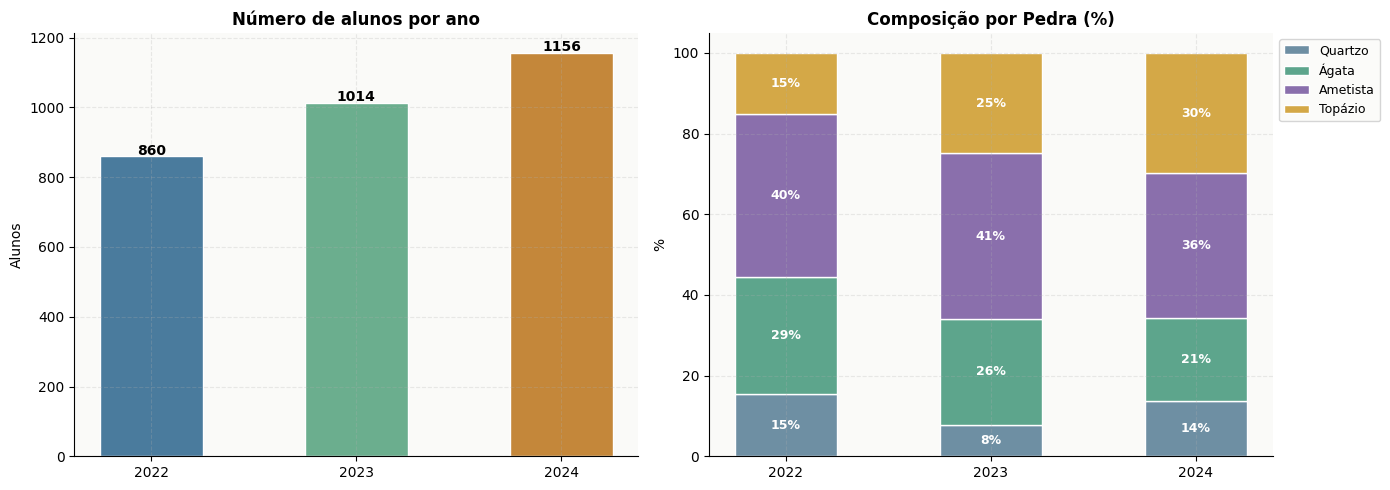

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alunos por ano
ax = axes[0]
contagem = df['Ano'].value_counts().sort_index()
bars = ax.bar(contagem.index, contagem.values,
              color=['#4A7B9D','#6BAE8E','#C4873A'], edgecolor='white', width=0.5)
for bar, v in zip(bars, contagem.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+5, str(v),
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('Número de alunos por ano', fontweight='bold')
ax.set_ylabel('Alunos'); ax.set_xticks([2022,2023,2024])

# Distribuição por Pedra
ax = axes[1]
CORES = {'Quartzo':'#6E8FA3','Ágata':'#5DA58C','Ametista':'#8A6FAC','Topázio':'#D4A847'}
pedra_ano = df.groupby(['Ano','Pedra'], observed=True).size().unstack(fill_value=0)
pedra_pct = pedra_ano.div(pedra_ano.sum(axis=1), axis=0) * 100
bottom = np.zeros(3)
for p in ['Quartzo','Ágata','Ametista','Topázio']:
    if p in pedra_pct.columns:
        vals = pedra_pct[p].values
        bars = ax.bar([2022,2023,2024], vals, bottom=bottom,
                      label=p, color=CORES[p], edgecolor='white', width=0.5)
        for bar, v in zip(bars, vals):
            if v > 5:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_y()+v/2,
                        f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += vals
ax.set_title('Composição por Pedra (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xticks([2022,2023,2024])
ax.legend(bbox_to_anchor=(1,1), fontsize=9)

plt.tight_layout()
plt.savefig('../src/00_visao_geral.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Distribuição dos indicadores

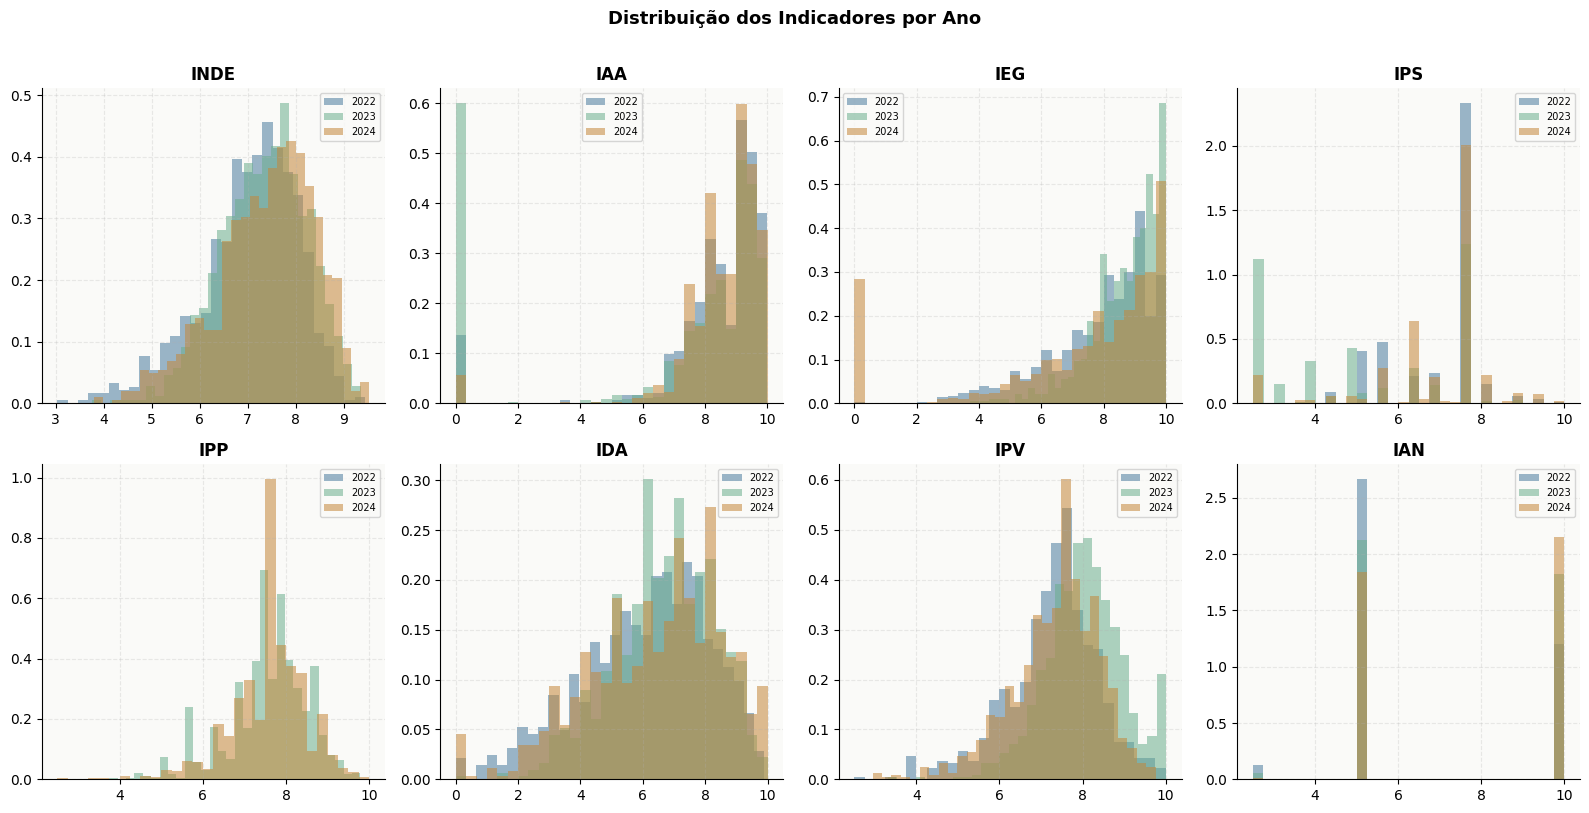

In [8]:
indicadores = ['INDE','IAA','IEG','IPS','IPP','IDA','IPV','IAN']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

CORES_ANOS = {2022:'#4A7B9D', 2023:'#6BAE8E', 2024:'#C4873A'}

for i, ind in enumerate(indicadores):
    ax = axes[i]
    for ano, c in CORES_ANOS.items():
        vals = df[df['Ano']==ano][ind].dropna()
        vals.hist(ax=ax, bins=30, alpha=0.55, color=c, label=str(ano), density=True)
    ax.set_title(f'{ind}', fontweight='bold')
    ax.set_xlabel(''); ax.legend(fontsize=7)

plt.suptitle('Distribuição dos Indicadores por Ano', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../src/00_distribuicao_indicadores.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Salvar dataset consolidado

> Execute esta célula para salvar o dataset limpo que será usado nos próximos notebooks.


In [9]:
import os
os.makedirs('../data', exist_ok=True)
df.to_pickle('../data/df_consolidado.pkl')
print(f"Salvo em ../data/df_consolidado.pkl")
print(f"Shape: {df.shape}")


Salvo em ../data/df_consolidado.pkl
Shape: (3030, 18)


---
## Conclusões da Exploração

- **3 anos** de dados (2022–2024) com **~3.000 alunos** no total
- Indicadores principais: `INDE`, `IDA`, `IEG`, `IPS`, `IPP`, `IAA`, `IPV`, `IAN`
- Coluna `IPP` ausente em 2022 (imputar com mediana no notebook de modelo)
- Sistema de **Pedras** segmenta alunos por INDE: Quartzo → Ágata → Ametista → Topázio
- Proporção de Topázio cresceu de **15% (2022)** para **28% (2024)** — sinal positivo de impacto

> Próximo passo: `02_analise_perguntas.ipynb`
